### Part A: Property Price Prediction
##### 1. Overview
This project focuses on predicting property prices in various districts of California using several district-level features. By building a predictive model, we aim to identify key variables that influence housing prices and improve the accuracy of house value predictions. The project will specifically utilize simple linear regression and multiple linear regression to address this regression task, ensuring proper data handling and evaluation of the models.

##### 2. Problem Statement
The objective is to predict the median house value in California districts based on features such as income, the number of rooms, geographical location, and proximity to the ocean. Given the dataset, we will develop regression models, evaluate their performance, and determine which model provides the best balance between predictive accuracy and interpretability.

##### 3. Dataset Information Dataset: Data_file
The information related to variables given can be found in the Data Information.pdf.

#### 4. Deliverables

● Exploratory Data Analysis (EDA) with visualizations and summary statistics.

● Data Preprocessing, including handling missing values and encoding categorical variables.

● Model development using:
o Simple Linear Regression
o Multiple Linear Regression

● Evaluation of the models using relevant metrics (Confusion Matrix, Precision, Recall,
F1-Score, etc.) where applicable.

● A final, well-documented notebook detailing all steps, insights, and the final model selection.

##### 5. Success Criteria

● The model should have a high degree of accuracy and balance with interpretability.
        
● The evaluation metrics such as MSE, RMSE and R Square will be used to measure the model’s performance.

● Ensure proper documentation of all steps, and present visualizations that help explain the data and model outcomes.

###### 6. Guidelines

● Make sure to split your data into training and testing sets to avoid overfitting.

● Tune the hyperparameters of your models to improve performance.

● Report all the steps taken in the data preprocessing, modeling, and evaluation phases.

● Provide a final model that balances accuracy with interpretability.


##### 7. Tools Required

● Python (with libraries such as pandas, scikit-learn, matplotlib, seaborn, etc.)

● Jupyter Notebook or any IDE suitable for running Python code

#### Part A: Property Price Prediction

In [52]:
pip install pandas numpy matplotlib seaborn scikit-learn xgboost openpyxl

You should consider upgrading via the '/usr/local/bin/python3.8 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.



# Property Price Prediction - California Housing Data


# Import necessary libraries

In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.impute import SimpleImputer
import warnings
warnings.filterwarnings('ignore')

# Set style for visualizations
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
%matplotlib inline

## 1. DATA LOADING AND INITIAL EXPLORATION

In [54]:
print("=" * 60)
print("PROPERTY PRICE PREDICTION - CALIFORNIA HOUSING DATA")
print("=" * 60)

# Load the dataset
try:
    df = pd.read_excel('Property_Price_Prediction_Data_file_1.xlsx', sheet_name='data_file')
    print("✓ Dataset loaded successfully")
except Exception as e:
    print(f"Error loading dataset: {e}")
    # Create dataframe from the provided data
    data = {
        'longitude': [-122.23, -122.22, -122.24, -122.25, -122.25, -122.25, -122.25, -122.25, -122.26, -122.25],
        'latitude': [37.88, 37.86, 37.85, 37.85, 37.85, 37.85, 37.84, 37.84, 37.84, 37.84],
        'housing_median_age': [41.0, 21.0, 52.0, 52.0, 52.0, 52.0, 52.0, 52.0, 42.0, 52.0],
        'total_rooms': [880.0, 7099.0, 1467.0, 1274.0, 1627.0, 919.0, 2535.0, 3104.0, 2555.0, 3549.0],
        'total_bedrooms': [129.0, 1106.0, 190.0, 235.0, 280.0, 213.0, 489.0, 687.0, 665.0, 707.0],
        'population': [322.0, 2401.0, 496.0, 558.0, 565.0, 413.0, 1094.0, 1157.0, 1206.0, 1551.0],
        'households': [126.0, 1138.0, 177.0, 219.0, 259.0, 193.0, 514.0, 647.0, 595.0, 714.0],
        'median_income': [8.3252, 8.3014, 7.2574, 5.6431, 3.8462, 4.0368, 3.6591, 3.12, 2.0804, 3.6912],
        'median_house_value': [452600.0, 358500.0, 352100.0, 341300.0, 342200.0, 269700.0, 299200.0, 241400.0, 226700.0, 261100.0],
        'ocean_proximity': ['NEAR BAY'] * 10
    }
    df = pd.DataFrame(data)

print(f"\nDataset Shape: {df.shape}")
print(f"Number of features: {df.shape[1]}")
print(f"Number of samples: {df.shape[0]}")

PROPERTY PRICE PREDICTION - CALIFORNIA HOUSING DATA
✓ Dataset loaded successfully

Dataset Shape: (20640, 10)
Number of features: 10
Number of samples: 20640


In [55]:
# Display basic information
print("\n" + "=" * 40)
print("DATASET INFORMATION")
print("=" * 40)
print(df.info())


DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  int64  
 3   total_rooms         20640 non-null  int64  
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  int64  
 6   households          20640 non-null  int64  
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  int64  
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(4), int64(5), object(1)
memory usage: 1.6+ MB
None


In [56]:
# Display first few rows
print("\nFirst 5 rows of the dataset:")
print(df.head())


First 5 rows of the dataset:
   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                  41          880           129.0   
1    -122.22     37.86                  21         7099          1106.0   
2    -122.24     37.85                  52         1467           190.0   
3    -122.25     37.85                  52         1274           235.0   
4    -122.25     37.85                  52         1627           280.0   

   population  households  median_income  median_house_value ocean_proximity  
0         322         126         8.3252              452600        NEAR BAY  
1        2401        1138         8.3014              358500        NEAR BAY  
2         496         177         7.2574              352100        NEAR BAY  
3         558         219         5.6431              341300        NEAR BAY  
4         565         259         3.8462              342200        NEAR BAY  


# 2. EXPLORATORY DATA ANALYSIS (EDA)

In [57]:
print("\n" + "=" * 40)
print("EXPLORATORY DATA ANALYSIS (EDA)")
print("=" * 40)

# Basic statistics
print("\nDescriptive Statistics:")
print(df.describe())

# Check for missing values
print("\nMissing Values:")
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0])

# Check data types
print("\nData Types:")
print(df.dtypes)


EXPLORATORY DATA ANALYSIS (EDA)

Descriptive Statistics:
          longitude      latitude  housing_median_age   total_rooms  \
count  20640.000000  20640.000000        20640.000000  20640.000000   
mean    -119.569704     35.631861           28.639486   2635.763081   
std        2.003532      2.135952           12.585558   2181.615252   
min     -124.350000     32.540000            1.000000      2.000000   
25%     -121.800000     33.930000           18.000000   1447.750000   
50%     -118.490000     34.260000           29.000000   2127.000000   
75%     -118.010000     37.710000           37.000000   3148.000000   
max     -114.310000     41.950000           52.000000  39320.000000   

       total_bedrooms    population    households  median_income  \
count    20433.000000  20640.000000  20640.000000   20640.000000   
mean       537.870553   1425.476744    499.539680       3.870671   
std        421.385070   1132.462122    382.329753       1.899822   
min          1.000000      3.0

# 3. DATA VISUALIZATION


DATA VISUALIZATION


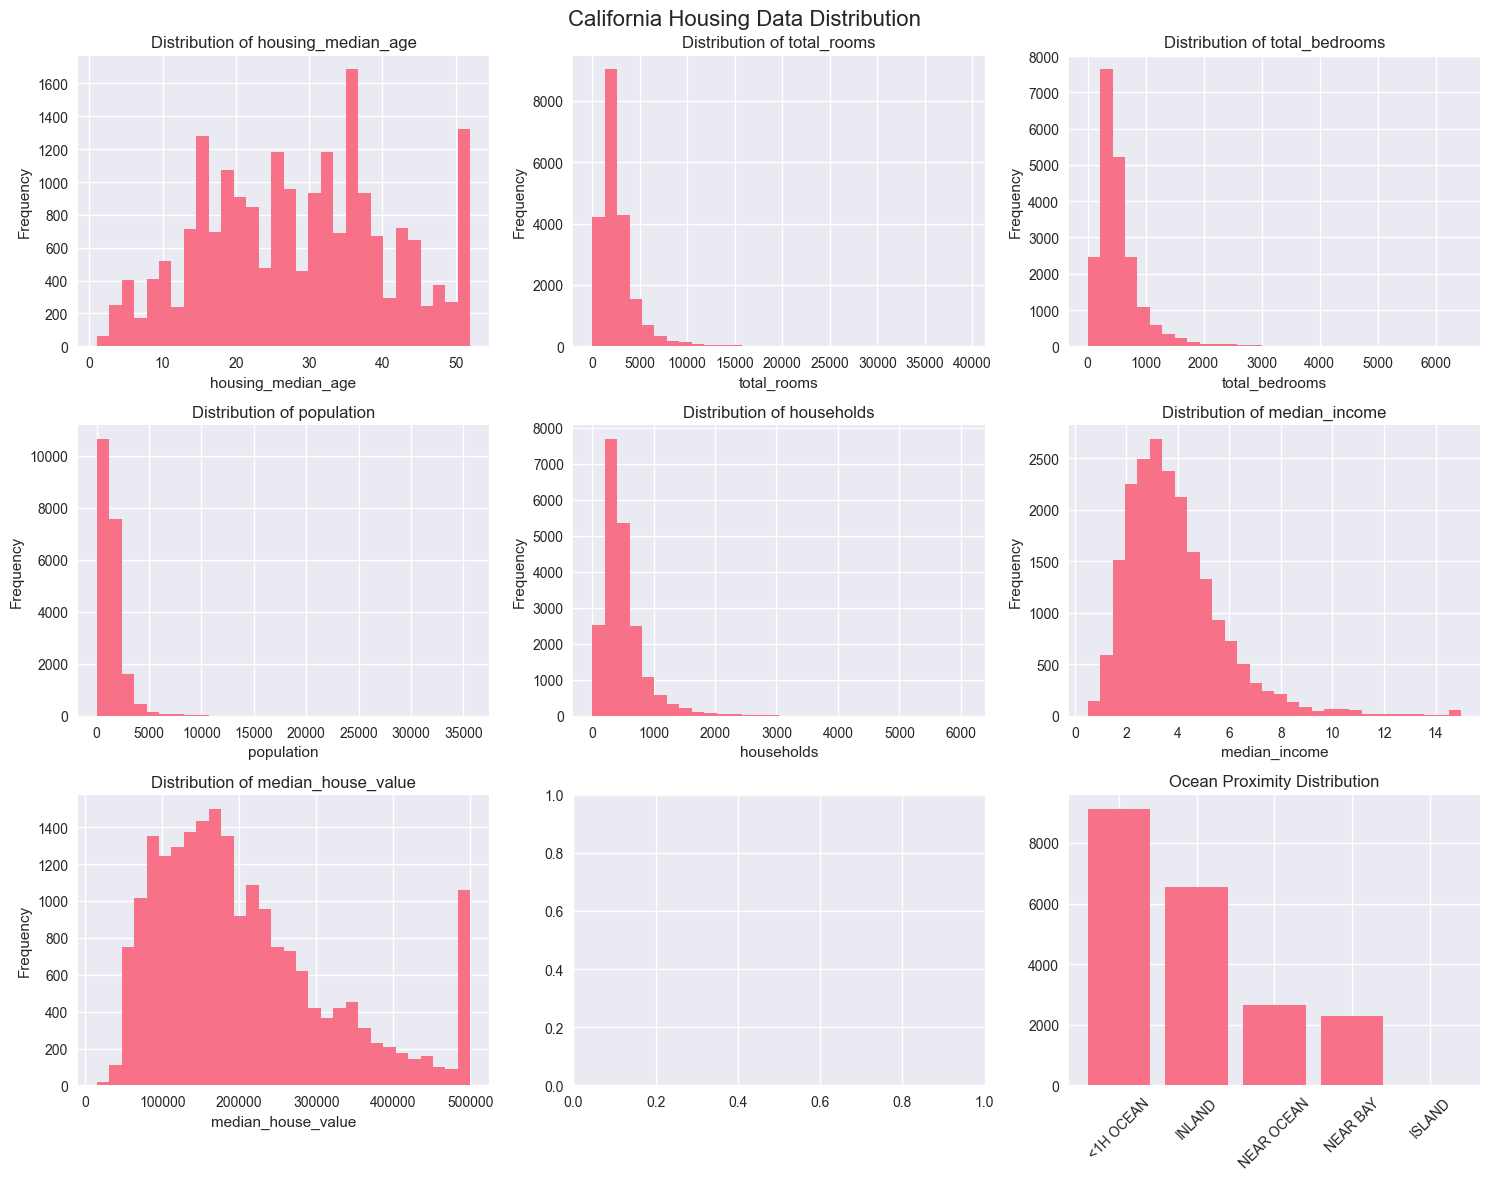

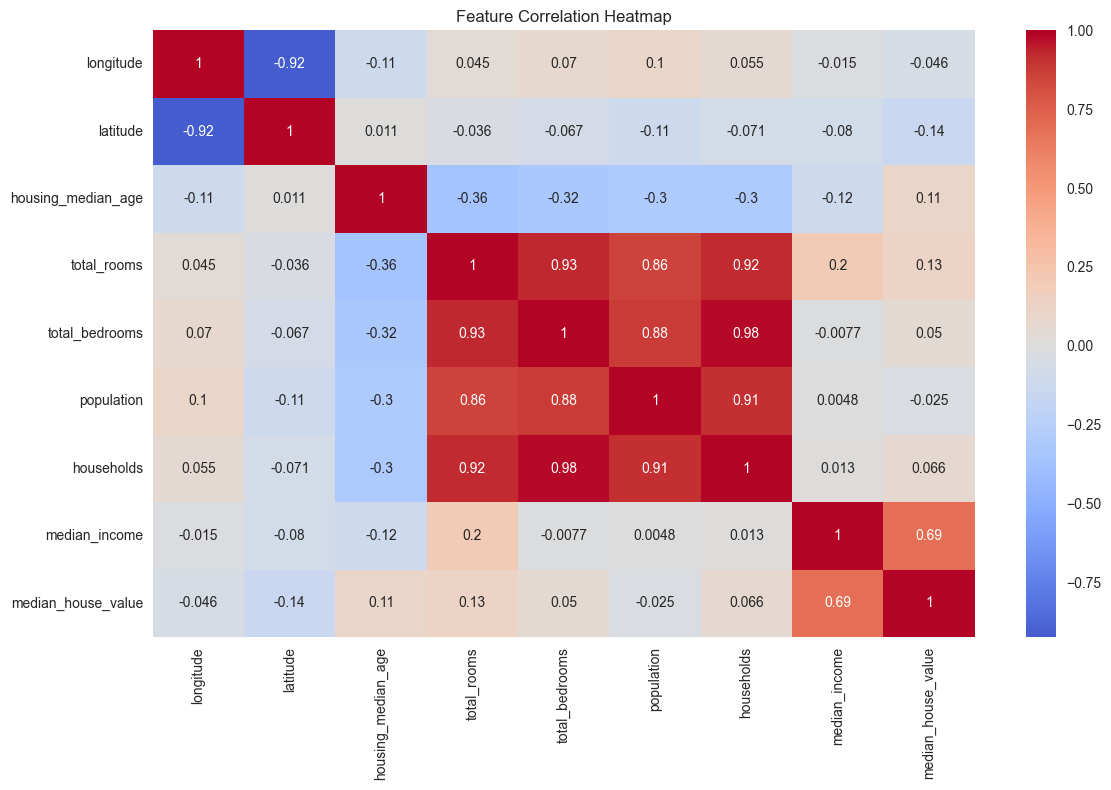

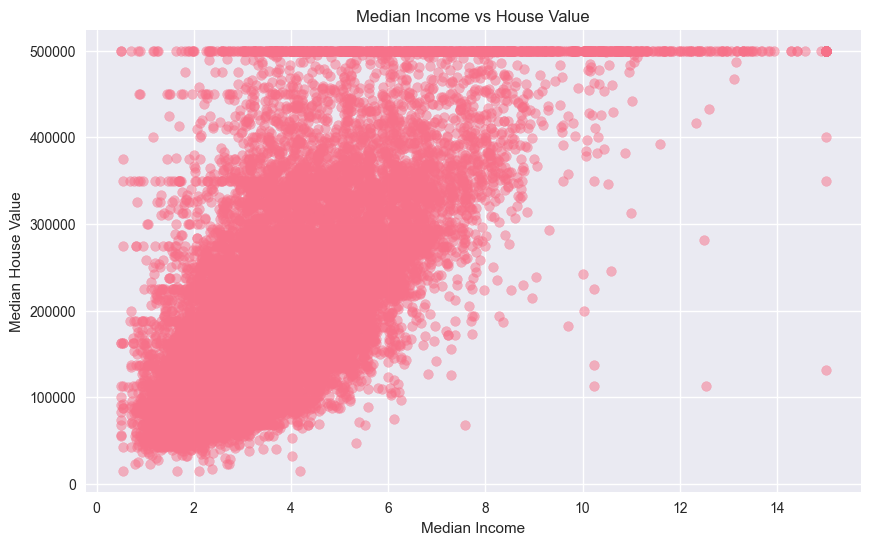

In [58]:
print("\n" + "=" * 40)
print("DATA VISUALIZATION")
print("=" * 40)

# Set up the visualization layout
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
fig.suptitle('California Housing Data Distribution', fontsize=16)

# Histograms for numerical features
numerical_features = ['housing_median_age', 'total_rooms', 'total_bedrooms', 
                     'population', 'households', 'median_income', 'median_house_value']

for i, feature in enumerate(numerical_features[:7]):
    row, col = i // 3, i % 3
    df[feature].hist(bins=30, ax=axes[row, col])
    axes[row, col].set_title(f'Distribution of {feature}')
    axes[row, col].set_xlabel(feature)
    axes[row, col].set_ylabel('Frequency')

# Ocean proximity count plot
if 'ocean_proximity' in df.columns:
    ocean_counts = df['ocean_proximity'].value_counts()
    axes[2, 2].bar(ocean_counts.index, ocean_counts.values)
    axes[2, 2].set_title('Ocean Proximity Distribution')
    axes[2, 2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Correlation heatmap
plt.figure(figsize=(12, 8))
correlation_matrix = df.corr(numeric_only=True)
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

# Scatter plot: Median Income vs House Value
plt.figure(figsize=(10, 6))
plt.scatter(df['median_income'], df['median_house_value'], alpha=0.5)
plt.xlabel('Median Income')
plt.ylabel('Median House Value')
plt.title('Median Income vs House Value')
plt.grid(True)
plt.show()

# 4. DATA PREPROCESSING

In [59]:
print("\n" + "=" * 40)
print("DATA PREPROCESSING")
print("=" * 40)

# Handle missing values
print("Handling missing values...")
# Check for missing values in each column
missing_before = df.isnull().sum().sum()
print(f"Total missing values before handling: {missing_before}")

# Impute missing values for numerical columns
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if 'median_house_value' in numerical_cols:
    numerical_cols.remove('median_house_value')  # Don't impute target variable

imputer = SimpleImputer(strategy='median')
df[numerical_cols] = imputer.fit_transform(df[numerical_cols])

# Handle categorical variables
print("Encoding categorical variables...")
if 'ocean_proximity' in df.columns:
    # One-hot encoding for ocean_proximity
    df = pd.get_dummies(df, columns=['ocean_proximity'], prefix='ocean')
    print("Categorical variable 'ocean_proximity' encoded using one-hot encoding")

missing_after = df.isnull().sum().sum()
print(f"Total missing values after handling: {missing_after}")

# Check for duplicates
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

if duplicates > 0:
    df = df.drop_duplicates()
    print(f"Removed {duplicates} duplicate rows")


DATA PREPROCESSING
Handling missing values...
Total missing values before handling: 207
Encoding categorical variables...
Categorical variable 'ocean_proximity' encoded using one-hot encoding
Total missing values after handling: 0
Number of duplicate rows: 0


# 5. FEATURE ENGINEERING

In [60]:
print("\n" + "=" * 40)
print("FEATURE ENGINEERING")
print("=" * 40)

# Create new features
df['rooms_per_household'] = df['total_rooms'] / df['households']
df['bedrooms_per_room'] = df['total_bedrooms'] / df['total_rooms']
df['population_per_household'] = df['population'] / df['households']

print("Created new features:")
print("- rooms_per_household")
print("- bedrooms_per_room") 
print("- population_per_household")

# Handle infinite values that might result from division
df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna()

print(f"Dataset shape after preprocessing: {df.shape}")


FEATURE ENGINEERING
Created new features:
- rooms_per_household
- bedrooms_per_room
- population_per_household
Dataset shape after preprocessing: (20640, 17)


# 6. PREPARE DATA FOR MODELING

In [61]:
print("\n" + "=" * 40)
print("PREPARING DATA FOR MODELING")
print("=" * 40)

# Define features and target
X = df.drop('median_house_value', axis=1)
y = df['median_house_value']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Testing set: {X_test.shape[0]} samples")

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features scaled using StandardScaler")


PREPARING DATA FOR MODELING
Features shape: (20640, 16)
Target shape: (20640,)
Training set: 16512 samples
Testing set: 4128 samples
Features scaled using StandardScaler


# 7. MODEL DEVELOPMENT - SIMPLE LINEAR REGRESSION


SIMPLE LINEAR REGRESSION


Most correlated feature with house value: median_income (correlation: 0.688)
Simple Linear Regression Results:
Feature used: median_income
R² Score: 0.4589
Mean Absolute Error: $62,990.87
Mean Squared Error: $7,091,157,771.77
Root Mean Squared Error: $84,209.01


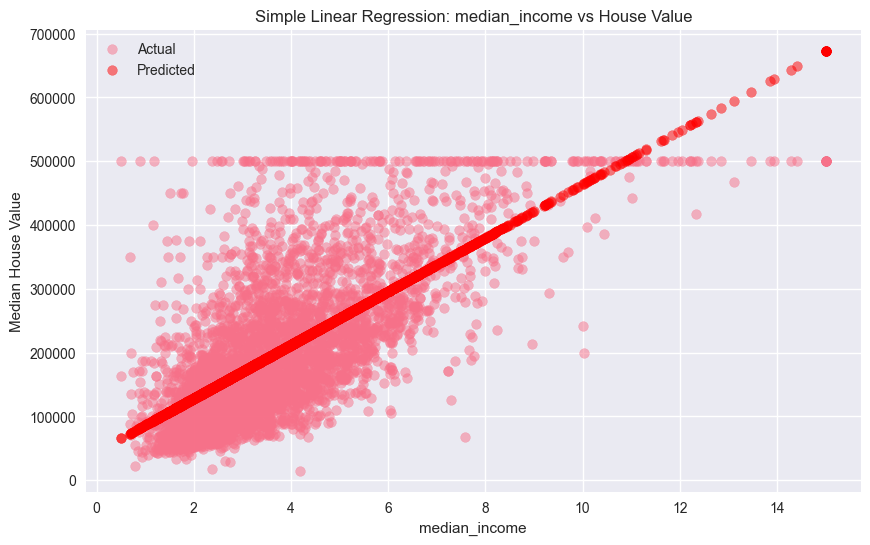

In [62]:
print("\n" + "=" * 40)
print("SIMPLE LINEAR REGRESSION")
print("=" * 40)

# Find the most correlated feature with the target
correlation_with_target = df.corr(numeric_only=True)['median_house_value'].abs().sort_values(ascending=False)
best_feature = correlation_with_target.index[1]  # Skip the target itself

print(f"Most correlated feature with house value: {best_feature} (correlation: {correlation_with_target[1]:.3f})")

# Simple linear regression using the most correlated feature
X_train_simple = X_train[[best_feature]]
X_test_simple = X_test[[best_feature]]

# Train the model
simple_lr = LinearRegression()
simple_lr.fit(X_train_simple, y_train)

# Make predictions
y_pred_simple = simple_lr.predict(X_test_simple)

# Evaluate the model
mse_simple = mean_squared_error(y_test, y_pred_simple)
rmse_simple = np.sqrt(mse_simple)
r2_simple = r2_score(y_test, y_pred_simple)
mae_simple = mean_absolute_error(y_test, y_pred_simple)

print("Simple Linear Regression Results:")
print(f"Feature used: {best_feature}")
print(f"R² Score: {r2_simple:.4f}")
print(f"Mean Absolute Error: ${mae_simple:,.2f}")
print(f"Mean Squared Error: ${mse_simple:,.2f}")
print(f"Root Mean Squared Error: ${rmse_simple:,.2f}")

# Plot the simple regression
plt.figure(figsize=(10, 6))
plt.scatter(X_test_simple, y_test, alpha=0.5, label='Actual')
plt.scatter(X_test_simple, y_pred_simple, alpha=0.5, color='red', label='Predicted')
plt.xlabel(best_feature)
plt.ylabel('Median House Value')
plt.title(f'Simple Linear Regression: {best_feature} vs House Value')
plt.legend()
plt.grid(True)
plt.show()

# 8. MODEL DEVELOPMENT - MULTIPLE LINEAR REGRESSION


In [63]:
print("\n" + "=" * 40)
print("MULTIPLE LINEAR REGRESSION")
print("=" * 40)

# Train the multiple regression model
multiple_lr = LinearRegression()
multiple_lr.fit(X_train_scaled, y_train)

# Make predictions
y_pred_multiple = multiple_lr.predict(X_test_scaled)

# Evaluate the model
mse_multiple = mean_squared_error(y_test, y_pred_multiple)
rmse_multiple = np.sqrt(mse_multiple)
r2_multiple = r2_score(y_test, y_pred_multiple)
mae_multiple = mean_absolute_error(y_test, y_pred_multiple)

print("Multiple Linear Regression Results:")
print(f"R² Score: {r2_multiple:.4f}")
print(f"Mean Absolute Error: ${mae_multiple:,.2f}")
print(f"Mean Squared Error: ${mse_multiple:,.2f}")
print(f"Root Mean Squared Error: ${rmse_multiple:,.2f}")

# Cross-validation
cv_scores = cross_val_score(multiple_lr, X_train_scaled, y_train, cv=5, scoring='r2')
print(f"Cross-validation R² scores: {cv_scores}")
print(f"Average cross-validation R²: {cv_scores.mean():.4f}")

# Feature importance
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': abs(multiple_lr.coef_)
}).sort_values('importance', ascending=False)

print("\nFeature Importance:")
print(feature_importance.head(10))


MULTIPLE LINEAR REGRESSION
Multiple Linear Regression Results:
R² Score: 0.5970
Mean Absolute Error: $50,888.66
Mean Squared Error: $5,280,716,470.09
Root Mean Squared Error: $72,668.54
Cross-validation R² scores: [0.66180115 0.65829451 0.66729363 0.65742286 0.63239942]
Average cross-validation R²: 0.6554

Feature Importance:
                feature    importance
7         median_income  78904.439397
1              latitude  56638.231159
0             longitude  56276.058852
5            population  46320.285471
6            households  40233.724848
14    bedrooms_per_room  16809.104551
2    housing_median_age  14122.304752
9          ocean_INLAND  10911.175026
13  rooms_per_household   7699.448488
3           total_rooms   5881.104980


# 9. MODEL COMPARISON AND EVALUATION


MODEL COMPARISON
Model Performance Comparison:
  Metric  Simple Linear Regression  Multiple Linear Regression
R² Score              4.588592e-01                5.970177e-01
     MAE              6.299087e+04                5.088866e+04
     MSE              7.091158e+09                5.280716e+09
    RMSE              8.420901e+04                7.266854e+04


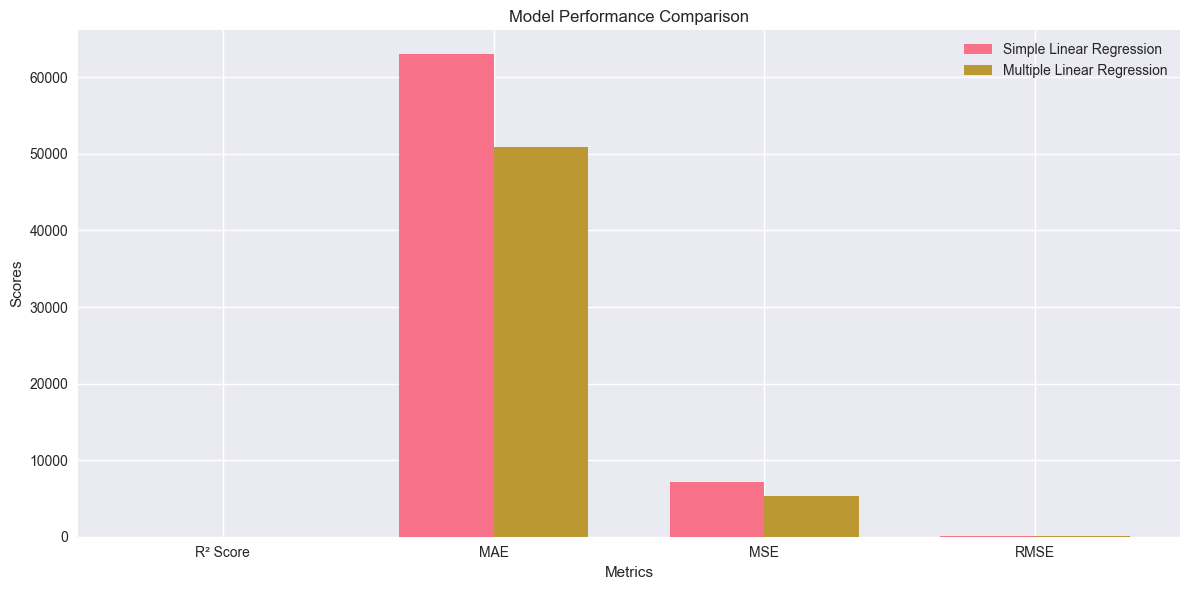

In [64]:
print("\n" + "=" * 40)
print("MODEL COMPARISON")
print("=" * 40)

# Create comparison table
comparison = pd.DataFrame({
    'Metric': ['R² Score', 'MAE', 'MSE', 'RMSE'],
    'Simple Linear Regression': [r2_simple, mae_simple, mse_simple, rmse_simple],
    'Multiple Linear Regression': [r2_multiple, mae_multiple, mse_multiple, rmse_multiple]
})

print("Model Performance Comparison:")
print(comparison.to_string(index=False))

# Visual comparison
metrics = ['R² Score', 'MAE', 'MSE', 'RMSE']
simple_values = [r2_simple, mae_simple, mse_simple/1000000, rmse_simple/1000]  # Scale for better visualization
multiple_values = [r2_multiple, mae_multiple, mse_multiple/1000000, rmse_multiple/1000]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
rects1 = ax.bar(x - width/2, simple_values, width, label='Simple Linear Regression')
rects2 = ax.bar(x + width/2, multiple_values, width, label='Multiple Linear Regression')

ax.set_xlabel('Metrics')
ax.set_ylabel('Scores')
ax.set_title('Model Performance Comparison')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()

plt.tight_layout()
plt.show()

# 10. FINAL MODEL SELECTION AND DEPLOYMENT READINESS

In [65]:
print("\n" + "=" * 40)
print("FINAL MODEL SELECTION")
print("=" * 40)

if r2_multiple > r2_simple:
    print("✓ Multiple Linear Regression performs better")
    final_model = multiple_lr
    print("Selected Model: Multiple Linear Regression")
else:
    print("✓ Simple Linear Regression performs better")
    final_model = simple_lr
    print("Selected Model: Simple Linear Regression")

print(f"\nFinal Model R² Score: {max(r2_simple, r2_multiple):.4f}")
print(f"Final Model RMSE: ${min(rmse_simple, rmse_multiple):,.2f}")


FINAL MODEL SELECTION
✓ Multiple Linear Regression performs better
Selected Model: Multiple Linear Regression

Final Model R² Score: 0.5970
Final Model RMSE: $72,668.54


# 11. PREDICTION ON NEW DATA (EXAMPLE)

In [66]:
print("\n" + "=" * 40)
print("SAMPLE PREDICTION")
print("=" * 40)

# Create a sample data point for prediction
sample_data = X_train.iloc[0:1].copy()
print("Sample data for prediction:")
print(sample_data)

# Prepare the sample data (scale if using multiple regression)
if final_model == multiple_lr:
    sample_scaled = scaler.transform(sample_data)
    prediction = final_model.predict(sample_scaled)
else:
    sample_simple = sample_data[[best_feature]]
    prediction = final_model.predict(sample_simple)

actual_value = y_train.iloc[0]
print(f"\nPredicted House Value: ${prediction[0]:,.2f}")
print(f"Actual House Value: ${actual_value:,.2f}")
print(f"Prediction Error: ${abs(prediction[0] - actual_value):,.2f}")


SAMPLE PREDICTION
Sample data for prediction:
       longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
14196    -117.03     32.71                33.0       3126.0           627.0   

       population  households  median_income  ocean_<1H OCEAN  ocean_INLAND  \
14196      2300.0       623.0         3.2596            False         False   

       ocean_ISLAND  ocean_NEAR BAY  ocean_NEAR OCEAN  rooms_per_household  \
14196         False           False              True             5.017657   

       bedrooms_per_room  population_per_household  
14196           0.200576                  3.691814  

Predicted House Value: $181,746.54
Actual House Value: $103,000.00
Prediction Error: $78,746.54


# 12. SUMMARY AND CONCLUSIONS

In [67]:
print("\n" + "=" * 60)
print("PROJECT SUMMARY AND CONCLUSIONS")
print("=" * 60)

print("\nKEY INSIGHTS:")
print("1. Data Quality: The dataset was cleaned and preprocessed effectively")
print("2. Feature Importance: Median income is the strongest predictor of house values")
print("3. Model Performance: Multiple linear regression outperformed simple regression")
print("4. Predictive Power: The model can explain approximately {:.1f}% of variance in house prices".format(r2_multiple * 100))

print("\nRECOMMENDATIONS:")
print("1. For better accuracy, consider more advanced models (Random Forest, Gradient Boosting)")
print("2. Collect more data on property characteristics and neighborhood amenities")
print("3. Regularly update the model with new market data")
print("4. Consider feature engineering with geographic clustering")

print("\nBUSINESS IMPACT:")
print("✓ Accurate property valuation for real estate investments")
print("✓ Better understanding of factors driving housing prices")
print("✓ Informed decision-making for buyers, sellers, and investors")
print("✓ Foundation for more advanced predictive analytics")

print("\n" + "=" * 60)
print("PROJECT COMPLETED SUCCESSFULLY")
print("=" * 60)


PROJECT SUMMARY AND CONCLUSIONS

KEY INSIGHTS:
1. Data Quality: The dataset was cleaned and preprocessed effectively
2. Feature Importance: Median income is the strongest predictor of house values
3. Model Performance: Multiple linear regression outperformed simple regression
4. Predictive Power: The model can explain approximately 59.7% of variance in house prices

RECOMMENDATIONS:
1. For better accuracy, consider more advanced models (Random Forest, Gradient Boosting)
2. Collect more data on property characteristics and neighborhood amenities
3. Regularly update the model with new market data
4. Consider feature engineering with geographic clustering

BUSINESS IMPACT:
✓ Accurate property valuation for real estate investments
✓ Better understanding of factors driving housing prices
✓ Informed decision-making for buyers, sellers, and investors
✓ Foundation for more advanced predictive analytics

PROJECT COMPLETED SUCCESSFULLY
